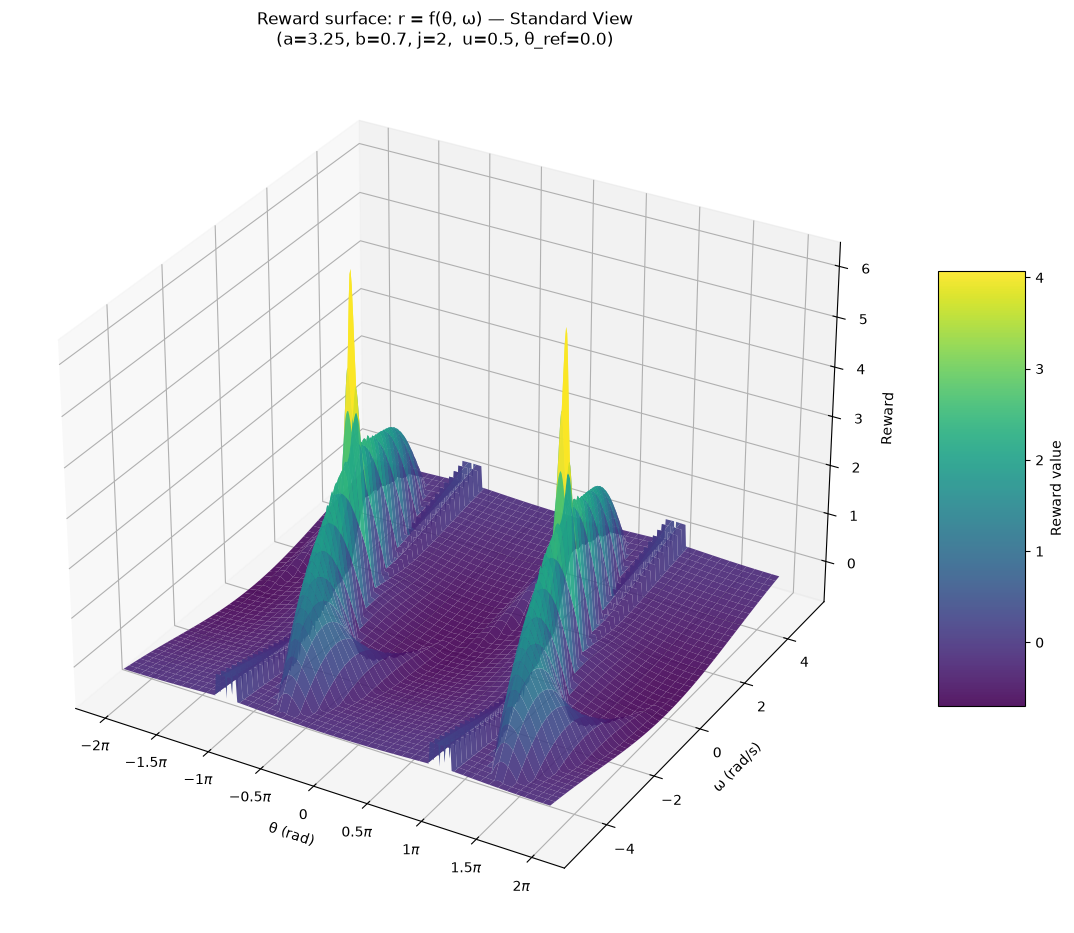

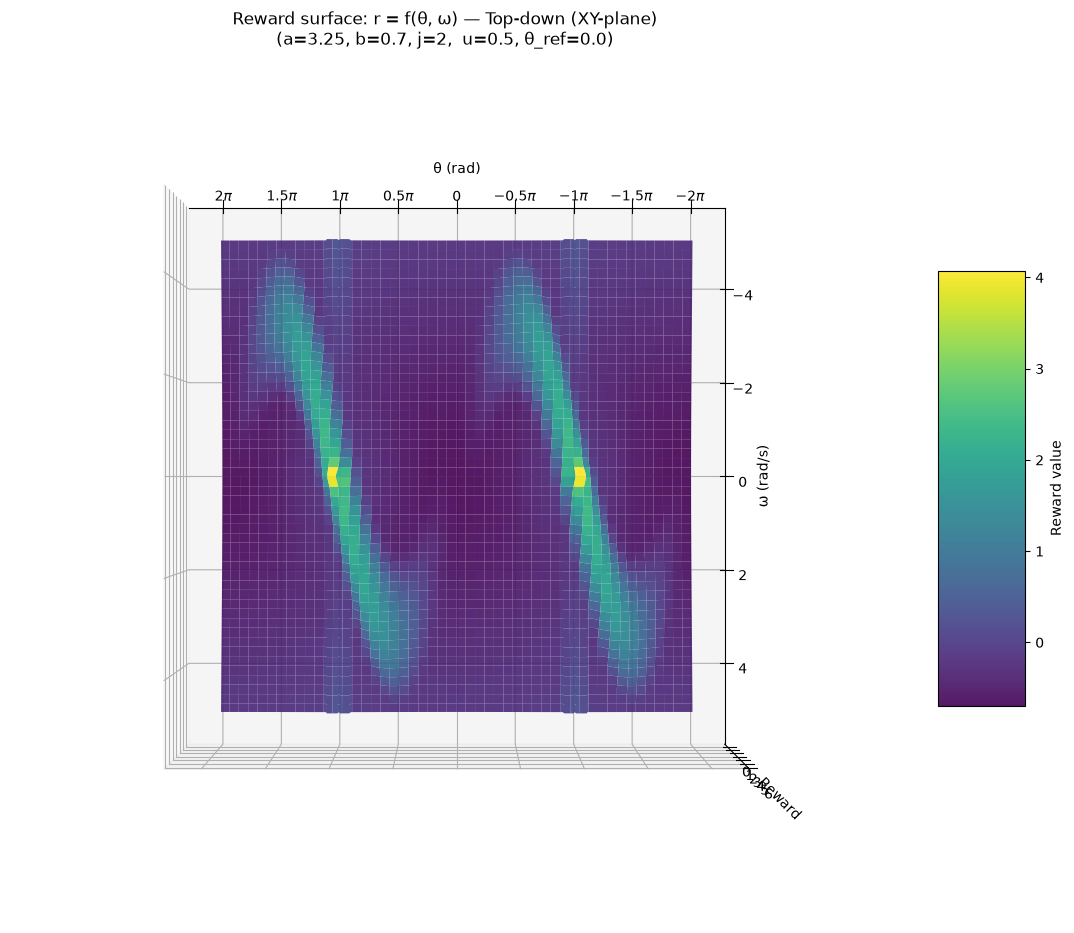

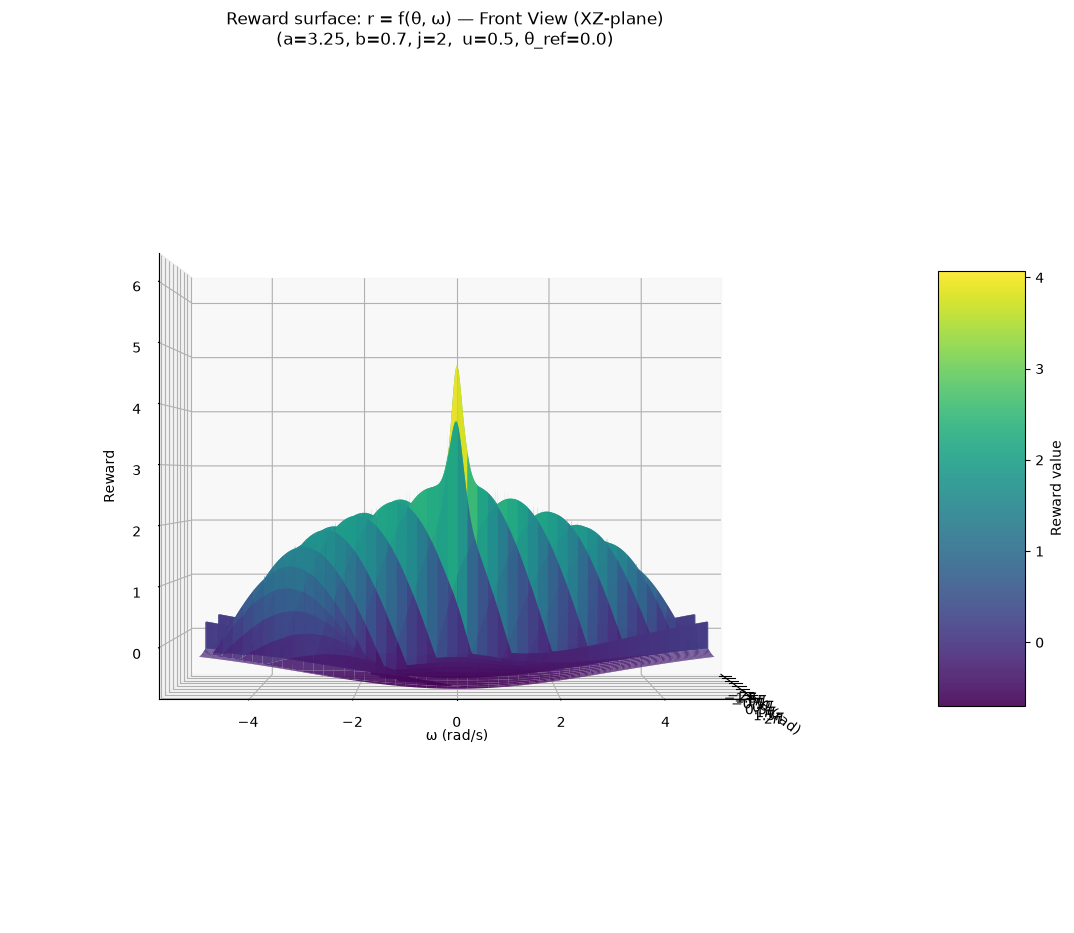

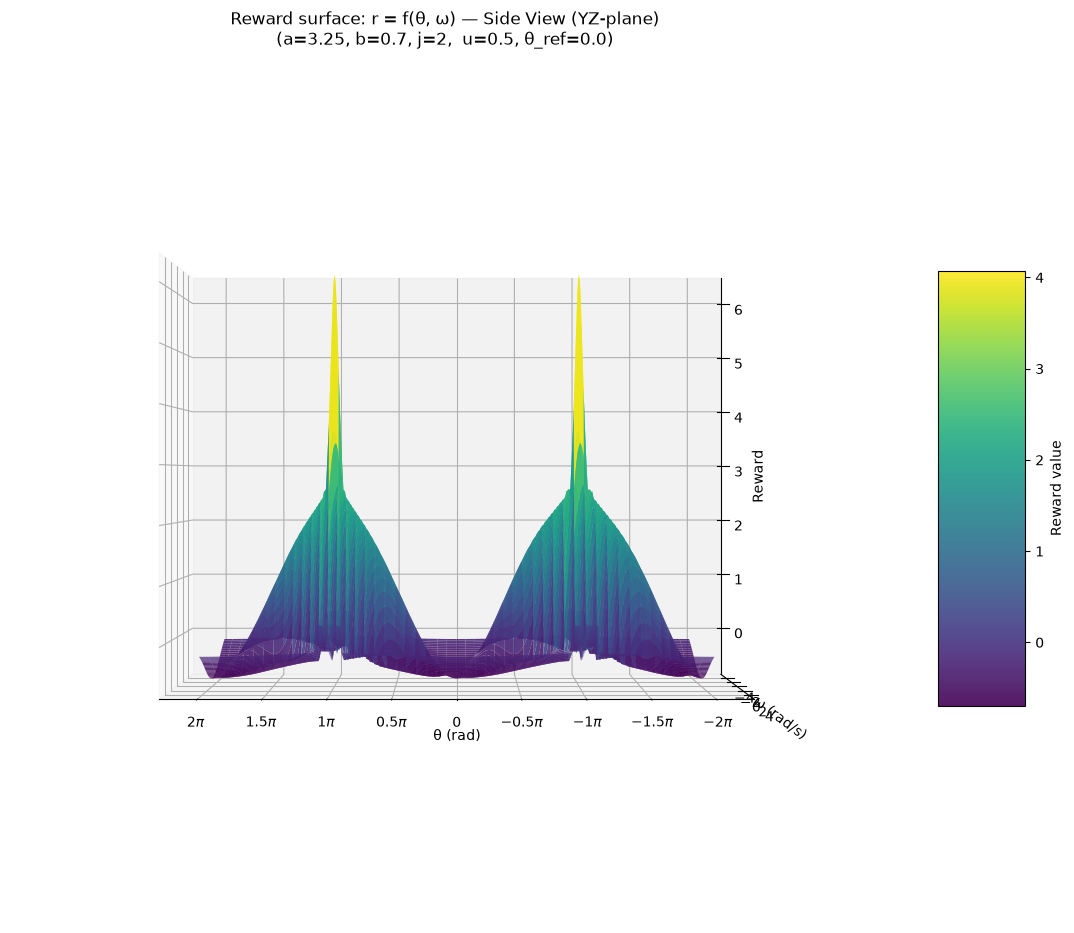

In [ ]:
"""
overview_test_reward.py
Visualises the reward landscape of the UnbalancedDisk environment as a
3D surface over the state space (angle θ, angular velocity ω).

The reward function is an *exact replica* of ``UnbalancedDiskDiscrete.py``
so that this standalone script always matches whatever the environment
currently computes.  All shaping constants are imported directly from the
environment class to keep the two in sync automatically.

Usage
-----
Run the script directly::

    python overview_test_reward.py

Four views of the surface are rendered in sequence:
  1. Standard perspective view
  2. Top-down (XY-plane)
  3. Front view (XZ-plane)
  4. Side view (YZ-plane)

Dependencies
------------
- numpy
- matplotlib
- UnbalancedDiskDiscrete  (local environment module)
"""

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

from UnbalancedDiskDiscrete import UnbalancedDisk


# ---------------------------------------------------------------------------
# Reward-shaping constants
# ---------------------------------------------------------------------------
# These are pulled *directly* from the environment so this plot always stays
# in sync with the actual reward signal used during training.

_env = UnbalancedDisk(render_mode=None)

TOP_GATE_SIGMA   = _env.TOP_GATE_SIGMA    # Std-dev of the gate around the top position
W_U_TOP          = _env.W_U_TOP           # Weight for the control-magnitude penalty (near top)
HOLD_OMEGA_SIGMA = _env.HOLD_OMEGA_SIGMA  # Std-dev of the gate around zero angular velocity
W_RATE_TOP       = _env.W_RATE_TOP        # Weight for the control-rate penalty (near top)
U_BOUND          = _env.U_BOUND           # Soft bound on |u| before a penalty kicks in
W_BOUND          = _env.W_BOUND           # Weight for the bound penalty
TOP5_SIGMA       = _env.TOP5_SIGMA        # Narrower std-dev gate used for bound/speed shaping
W_SPEED          = _env.W_SPEED           # Weight of the speed-encouragement reward
SPEED_BAND       = _env.SPEED_BAND        # (low, high) angular-error band where speed is rewarded
OMEGA_CAP        = _env.OMEGA_CAP         # Cap on |ω| used inside the speed reward

# NOTE: The two sharp-peak scales (0.3 and 0.05) are inlined in
#       ``reward_function_for_plot`` below.  Update them there if you change
#       their values inside the environment.

# ---------------------------------------------------------------------------
# Parameterisation of the Z-shape component
# ---------------------------------------------------------------------------
A_VALUE = 3.25  # Amplitude scaling of the sine argument shift  (controls horizontal spread)
B_VALUE = 0.7   # Vertical scale factor for the Z component
J_VALUE = 2     # Vertical offset / baseline shift in the Z component


# ---------------------------------------------------------------------------
# Helper functions
# ---------------------------------------------------------------------------

def calculate_z(x: np.ndarray, y: np.ndarray,
                a: float, b: float, j: float) -> np.ndarray:
    """Compute the Z-shape shaping component of the reward surface.

    The surface is defined by::

        term1 = sin(y - sin(x)*a + π/2)
        term2 = j + sin(x - π/2) * 2
        z     = term1 * b * term2

    Only points that satisfy **all** of the following constraints are kept;
    the rest are zeroed out:

    * ``sin(x)*a - π  ≤  y  ≤  sin(x)*a + π``   (y stays within one period
      of the shifted sine wave in x)
    * ``z  ≥  -j + 2``                            (lower bound on z)

    Parameters
    ----------
    x : np.ndarray
        Angle values (radians), typically a 2-D meshgrid array.
    y : np.ndarray
        Angular-velocity values (rad/s), same shape as *x*.
    a : float
        Horizontal spread parameter.
    b : float
        Vertical scale parameter.
    j : float
        Vertical offset parameter.

    Returns
    -------
    np.ndarray
        Filtered z-values; out-of-bounds points are replaced with 0.
    """
    # Core surface formula
    term1 = np.sin(y - np.sin(x) * a + 0.5 * np.pi)
    term2 = j + np.sin(x - 0.5 * np.pi) * 2
    z = term1 * b * term2

    # Constraint 1: y must lie within [sin(x)*a - π, sin(x)*a + π]
    condition_y_lower = np.sin(x) * a - np.pi
    condition_y_upper = np.sin(x) * a + np.pi

    # Constraint 2: z must be at least -j + 2
    condition_z_lower = -j + 2

    # Build a boolean mask; points that violate any constraint are zeroed out
    mask = (
        (y >= condition_y_lower) &
        (y <= condition_y_upper) &
        (z >= condition_z_lower)
    )

    return np.where(mask, z, 0)


def calculate_error(current_th: np.ndarray, target_th: float) -> np.ndarray:
    """Return the minimal angular distance between *current_th* and *target_th*.

    Angles are wrapped to the range [0, 2π) before comparison, so the result
    is always in [0, π].  This mirrors ``self.err`` in the environment.

    Parameters
    ----------
    current_th : np.ndarray
        Current angle(s) in radians.
    target_th : float
        Target angle in radians.

    Returns
    -------
    np.ndarray
        Absolute angular error in [0, π].
    """
    return np.abs(((current_th - target_th + np.pi) % (2 * np.pi)) - np.pi)


def gaussian_2d(val_x: np.ndarray, val_y: np.ndarray,
                mu_x: float, mu_y: float,
                sigma_x: float, sigma_y: float,
                rho: float, scale: float) -> np.ndarray:
    """Evaluate a scaled 2-D Gaussian at the given points.

    The Gaussian is parameterised by its mean (μ_x, μ_y), standard
    deviations (σ_x, σ_y), and correlation coefficient ρ.  An additional
    *scale* factor is applied on top of the normalisation constant so the
    peak height can be controlled independently of the spread.

    Parameters
    ----------
    val_x : np.ndarray
        x-coordinates at which to evaluate the Gaussian.
    val_y : np.ndarray
        y-coordinates at which to evaluate the Gaussian.
    mu_x : float
        Mean in the x-direction.
    mu_y : float
        Mean in the y-direction.
    sigma_x : float
        Standard deviation in the x-direction.
    sigma_y : float
        Standard deviation in the y-direction.
    rho : float
        Pearson correlation coefficient between x and y (in [-1, 1]).
    scale : float
        Multiplicative scaling factor applied to the Gaussian output.

    Returns
    -------
    np.ndarray
        Gaussian values with the same shape as *val_x* and *val_y*.
    """
    # Ensure inputs are at least 1-D so linalg operations work on scalars too
    val_x = np.atleast_1d(val_x)
    val_y = np.atleast_1d(val_y)

    mu  = np.array([mu_x, mu_y])
    cov = np.array([[sigma_x**2,               rho * sigma_x * sigma_y],
                    [rho * sigma_x * sigma_y,  sigma_y**2]])

    inv_cov = np.linalg.inv(cov)
    det_cov = np.linalg.det(cov)

    diff_x = val_x - mu[0]
    diff_y = val_y - mu[1]

    # Mahalanobis-style exponent (symmetric covariance → average off-diagonal terms)
    exponent = -0.5 * (
        inv_cov[0, 0] * diff_x**2 +
        (inv_cov[0, 1] + inv_cov[1, 0]) * diff_x * diff_y +
        inv_cov[1, 1] * diff_y**2
    )

    return scale * (1.0 / (2 * np.pi * np.sqrt(det_cov))) * np.exp(exponent)


# ---------------------------------------------------------------------------
# Reward function (exact replica of UnbalancedDisk.reward_fun)
# ---------------------------------------------------------------------------

def reward_function_for_plot(th_val: np.ndarray,
                              omega_val: np.ndarray,
                              th_ref_val: float = 0.0,
                              u_val: float = 0.5,
                              prev_u_val: float | None = None) -> np.ndarray:
    """Compute the full shaped reward over a (θ, ω) grid.

    This is an *exact replica* of ``UnbalancedDisk.reward_fun`` including
    all state and control terms.  It is kept separate so the reward surface
    can be evaluated over a grid without running the environment step-by-step.

    Reward components
    -----------------
    **State terms**

    * ``main_reward``        broad 2-D Gaussian centred at (e_top=0, ω=0);
      encourages staying at the top with low speed.
    * ``bottom_punishment``  wide, tall Gaussian at the bottom position;
      penalises being at or near the bottom equilibrium.
    * ``piek_15``            narrow peak (sigma=0.15) at the top for fine
      positioning incentive.
    * ``piek_07``           very narrow peak (sigma=0.07) for even finer
      positioning incentive.
    * ``Z_VALUES``           the Z-shape component that guides the agent
      along spiral-like trajectories toward the top.
    * ``speed_reward``       encourages higher |ω| when the angle is in a
      specific band around the top (helps swing-up).

    **Control terms** (all gated to activate only near the top position)

    * ``control_penalty``    penalises large control inputs.
    * ``rate_penalty``       penalises rapid changes in control input.
    * ``bound_penalty``      penalises |u| exceeding ``U_BOUND``.

    Parameters
    ----------
    th_val : np.ndarray
        Angle grid (radians).
    omega_val : np.ndarray
        Angular-velocity grid (rad/s).
    th_ref_val : float, optional
        Reference angle (radians).  Default is 0.0 (i.e. target is the top
        after the error is computed against π).
    u_val : float, optional
        Control input assumed for the plot.  Default is 0.5.
    prev_u_val : float or None, optional
        Previous control input used to compute the rate penalty.  If *None*,
        it defaults to *u_val*, which sets the rate penalty to zero (useful
        for a steady-state slice of the reward surface).

    Returns
    -------
    np.ndarray
        Total reward values over the input grid.
    """
    if prev_u_val is None:
        # Assume steady control so the rate penalty vanishes in this plot
        prev_u_val = u_val

    # Angular error with respect to the top position (θ = π)
    e_top = calculate_error(th_val, np.pi)

    # ------------------------------------------------------------------
    # Gating functions
    # These soft gates localise the control penalties to the region near
    # the top so they do not distort the reward elsewhere in state space.
    # ------------------------------------------------------------------
    top_gate  = np.exp(-0.55 * (e_top       / TOP_GATE_SIGMA)   ** 2)  # near top (angle)
    hold_gate = np.exp(-0.45 * (omega_val   / HOLD_OMEGA_SIGMA) ** 2)  # near zero speed
    top5_gate = np.exp(-0.50 * (e_top       / TOP5_SIGMA)       ** 2)  # tighter top gate

    # ------------------------------------------------------------------
    # State reward components
    # ------------------------------------------------------------------
    main_reward_component       = gaussian_2d(e_top, omega_val,
                                              0, 0, 1,  1,  0.0, 2)
    bottom_punishment_component = gaussian_2d(calculate_error(th_val, 0), omega_val,
                                              0, 0, 3,  3,  0.0, 40)
    piek_15 = gaussian_2d(e_top, omega_val, 0, 0, 0.15, 0.15, 0.0, 0.3)   # scale = 0.3
    piek_07 = gaussian_2d(e_top, omega_val, 0, 0, 0.07, 0.07, 0.0, 0.05)  # scale = 0.05
    Z_VALUES = calculate_z(th_val, omega_val, a=A_VALUE, b=B_VALUE, j=J_VALUE)

    # ------------------------------------------------------------------
    # Control-shaping terms (active only near the top)
    # ------------------------------------------------------------------
    # Penalise large control magnitude when near the top and near zero speed
    control_penalty = W_U_TOP   * top_gate  * hold_gate * u_val**2
    # Penalise rapid control changes when near the top
    rate_penalty    = W_RATE_TOP * top_gate  * (u_val - prev_u_val)**2
    # Penalise |u| exceeding U_BOUND when very close to the top and near zero speed
    bound_penalty   = W_BOUND   * top5_gate * hold_gate * np.maximum(0.0, np.abs(u_val) - U_BOUND)**2

    # Encourage speed when the angle error is within SPEED_BAND (helps swing-up)
    speed_reward = W_SPEED * (
        (e_top > SPEED_BAND[0]) & (e_top < SPEED_BAND[1])
    ) * np.clip(np.abs(omega_val), 0.0, OMEGA_CAP)

    # ------------------------------------------------------------------
    # Combine all components into the total reward
    # ------------------------------------------------------------------
    total_reward = (
          main_reward_component       # + broad Gaussian at top
        - bottom_punishment_component # - push away from bottom equilibrium
        + piek_15                     # + fine positioning peak
        + piek_07                     # + very fine positioning peak
        + Z_VALUES                    # + spiral-guidance shaping
        - control_penalty             # - large control near top
        - rate_penalty                # - rapid control changes near top
        - bound_penalty               # - exceeding control bound near top
        + speed_reward                # + speed encouragement during swing-up
    )
    return total_reward


# ---------------------------------------------------------------------------
# Grid setup
# ---------------------------------------------------------------------------

# θ-axis: full two-period sweep so wrap-around behaviour is visible
th_plot_range    = np.linspace(-2 * np.pi, 2 * np.pi, 400)  # angle (rad)
# ω-axis: covers the physically meaningful range of the disk's angular speed
omega_plot_range = np.linspace(-5, 5, 400)                    # angular velocity (rad/s)

# Build 2-D meshgrid for vectorised evaluation
TH_MESH, OMEGA_MESH = np.meshgrid(th_plot_range, omega_plot_range)

# Fixed values used for the control-related penalty terms in this surface plot.
# Adjust these to inspect how the reward changes with different operating points.
TH_REF_FOR_PLOT = 0.0  # Reference angle (rad) — irrelevant for the top-position reward
U_FOR_PLOT      = 0.5  # Constant control input (assumed steady → rate penalty = 0)

# Evaluate the full reward surface over the grid
Z_REWARD = reward_function_for_plot(
    TH_MESH, OMEGA_MESH,
    th_ref_val=TH_REF_FOR_PLOT,
    u_val=U_FOR_PLOT
)


# ---------------------------------------------------------------------------
# Plotting
# ---------------------------------------------------------------------------

# Four viewpoints to inspect different aspects of the reward surface
plot_views = [
    {'elev': 30, 'azim': -60, 'title_suffix': 'Standard View'},
    {'elev': 90, 'azim':  90, 'title_suffix': 'Top-down (XY-plane)'},
    {'elev':  0, 'azim':   0, 'title_suffix': 'Front View (XZ-plane)'},
    {'elev':  0, 'azim':  90, 'title_suffix': 'Side View (YZ-plane)'},
]

for view in plot_views:
    fig = plt.figure(figsize=(12, 9))
    ax  = fig.add_subplot(111, projection='3d')
    plt.tight_layout()

    # Axis labels and title
    ax.set_xlabel('θ (rad)')
    ax.set_ylabel('ω (rad/s)')
    ax.set_zlabel('Reward')
    ax.set_title(
        f'Reward surface: r = f(θ, ω) — {view["title_suffix"]}\n'
        f'(a={A_VALUE}, b={B_VALUE}, j={J_VALUE},  '
        f'u={U_FOR_PLOT}, θ_ref={TH_REF_FOR_PLOT})'
    )

    # ------------------------------------------------------------------
    # Custom x-axis tick labels expressed as multiples of π
    # ------------------------------------------------------------------
    x_tick_multipliers = np.array([-2, -1.5, -1, -0.5, 0, 0.5, 1, 1.5, 2])
    x_tick_values      = x_tick_multipliers * np.pi
    ax.set_xticks(x_tick_values)
    x_tick_labels = [
        f'${m:g}\\pi$' if m != 0 else '0'
        for m in x_tick_multipliers
    ]
    ax.set_xticklabels(x_tick_labels)

    # ------------------------------------------------------------------
    # Surface plot
    # ------------------------------------------------------------------
    surf = ax.plot_surface(
        TH_MESH, OMEGA_MESH, Z_REWARD,
        cmap='viridis', edgecolor='none', alpha=0.9
    )
    fig.colorbar(surf, shrink=0.5, aspect=5, label='Reward value')

    # Apply the camera angle for this view
    ax.view_init(elev=view['elev'], azim=view['azim'])

    plt.show()